Portfolio return

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
assets = ['MSFT', 'AAPL', 'AMZN', 'TSLA', 'GOOGL']
w = np.array([0.1, 0.2, 0.1, 0.4, 0.2]) # Weights of each asset
asset_prices = pd.read_csv("C:/Users/pc/Downloads/portfolio_prices.csv", index_col = "Date", parse_dates = True)
r = asset_prices.pct_change().dropna() # Calculating daily percent returns
r.head()
r_port = r @ w 

,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.004654,-0.010233
2018-01-04,0.004645,0.004476,0.003884,0.008802,-0.008290
2018-01-05,0.011385,0.016163,0.013260,0.012398,0.006230
2018-01-08,-0.003714,0.014425,0.003531,0.001020,0.062638
2018-01-09,-0.000115,0.004676,-0.001274,-0.000680,-0.008085


In [4]:
r_port = r @ w # Creating portfolio returns
r_port.name = 'portfolio_returns'
r_port.head()

Date
2018-01-03    0.004059
2018-01-04    0.003611
2018-01-05    0.011902
2018-01-08    0.015802
2018-01-09   -0.001093
Name: portfolio_returns, dtype: float64

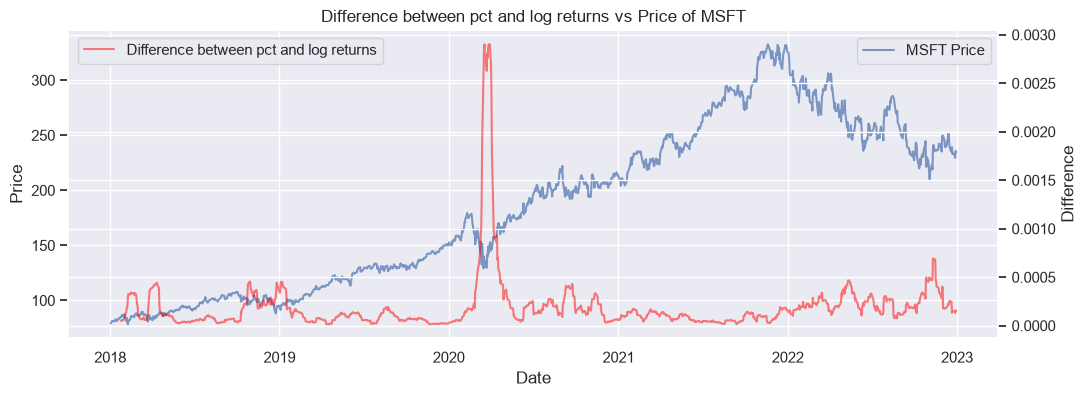

In [5]:
# Figure 1 it show difference between Arthimetric return and log return  

pct_returns_msft = asset_prices['MSFT'].pct_change().dropna() # Calculating pct returns
log_returns_msft = np.log(asset_prices['MSFT'] / asset_prices['MSFT'].shift(1)).dropna() # Calculating log returns

pct_change_msft_roll_mean = pct_returns_msft.rolling(15).mean() # Rolling average of pct returns
log_returns_msft_roll_mean = log_returns_msft.rolling(15).mean() # Rolling average of log returns

fig, ax = plt.subplots(figsize=(12,4))
ax.set_title('Difference between pct and log returns vs Price of MSFT')
ax.plot(asset_prices['MSFT'], label = 'MSFT Price', alpha = 0.7)
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend()

ax2 = ax.twinx()
ax2.plot((pct_change_msft_roll_mean - log_returns_msft_roll_mean), color = 'red', alpha = 0.5, label = 'Difference between pct and log returns')
ax2.set_ylabel('Difference')
ax2.legend(loc = (0.01,0.89))
plt.show()

In [6]:
percent_returns_tsla = asset_prices['TSLA'].loc["2020-06-01":"2020-09-30"].pct_change().dropna() # Calculating daily percent returns
geom_mean_tsla_1 = ((1 + percent_returns_tsla).prod() ** (1/len(percent_returns_tsla))) - 1 # Calculating geometric mean

log_returns_tsla = np.log(asset_prices['TSLA'].loc["2020-06-01":"2020-09-30"] / asset_prices['TSLA'].loc["2020-06-01":"2020-09-30"].shift(1)).dropna() # Calculating daily log returns
arithmetic_mean_tsla_1 = log_returns_tsla.mean() # Calculating arithmetic mean

print("Logarithm of geometric Mean of TSLA + 1: ", np.log(geom_mean_tsla_1 + 1))
print("Arithmetic Mean of TSLA: ", arithmetic_mean_tsla_1)

Logarithm of geometric Mean of TSLA + 1:  0.010242784447195914
Arithmetic Mean of TSLA:  0.010242784447195901


In [7]:
#Annualziation of return 
geom_mean_msft = ((1 + pct_returns_msft).prod() ** (1/len(pct_returns_msft))) - 1 # Calculating geometric mean
annual_pct_returns_msft = (1 + geom_mean_msft) ** 252 - 1 # Annualizing percent returns

annual_log_returns_msft = log_returns_msft.mean() * 252 # Annualizing log returns

print("Annualized pct returns of MSFT: ", annual_pct_returns_msft)
print("Annualized log returns of MSFT: ", annual_log_returns_msft)

Annualized pct returns of MSFT:  0.24306555153098586
Annualized log returns of MSFT:  0.21758054768754312


In [8]:
# portfolio varriance 
r_port.std() # Calculating standard deviation of portfolio returns

np.float64(0.020274896364979554)

In [9]:
port_var = w.T @ r.cov() @ w # Calculating portfolio variance
port_std = np.sqrt(port_var) # Calculating portfolio standard deviation

print("Portfolio variance: ", port_var)
print("Portfolio standard deviation: ", port_std)

Portfolio variance:  0.0004110714226106612
Portfolio standard deviation:  0.020274896364979554


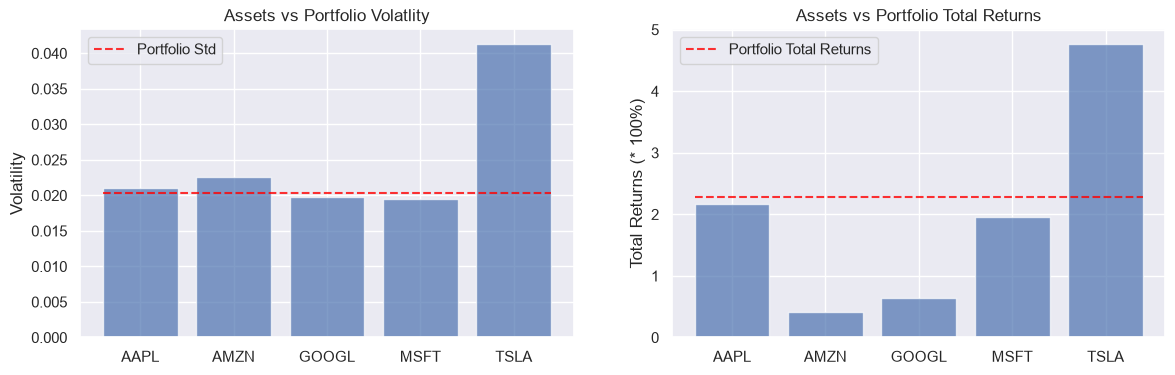

In [10]:
# Figure 2
# We will visualize the asset's std and returns vs portfolio

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14,4))

ax1.bar(x = r.columns, height = r.std(), alpha = 0.7)
ax1.hlines(y = port_std, xmin = -0.4, xmax = 4.4, linestyle = "--", color = 'red', alpha = 0.8, label = "Portfolio Std")
ax1.set_title("Assets vs Portfolio Volatlity")
ax1.set_ylabel("Volatility")
ax1.legend()

ax2.bar(x = r.columns, height = (r + 1).prod() - 1, alpha = 0.7) # Make sure you can explain why the `(r + 1).prod() - 1` is the total return
ax2.hlines(y = (r_port + 1).prod() - 1, xmin = -0.4, xmax = 4.4, linestyle = "--", color = 'red', alpha = 0.8, label = "Portfolio Total Returns")
ax2.set_title("Assets vs Portfolio Total Returns")
ax2.set_ylabel("Total Returns (* 100%)")
ax2.legend()

plt.show()

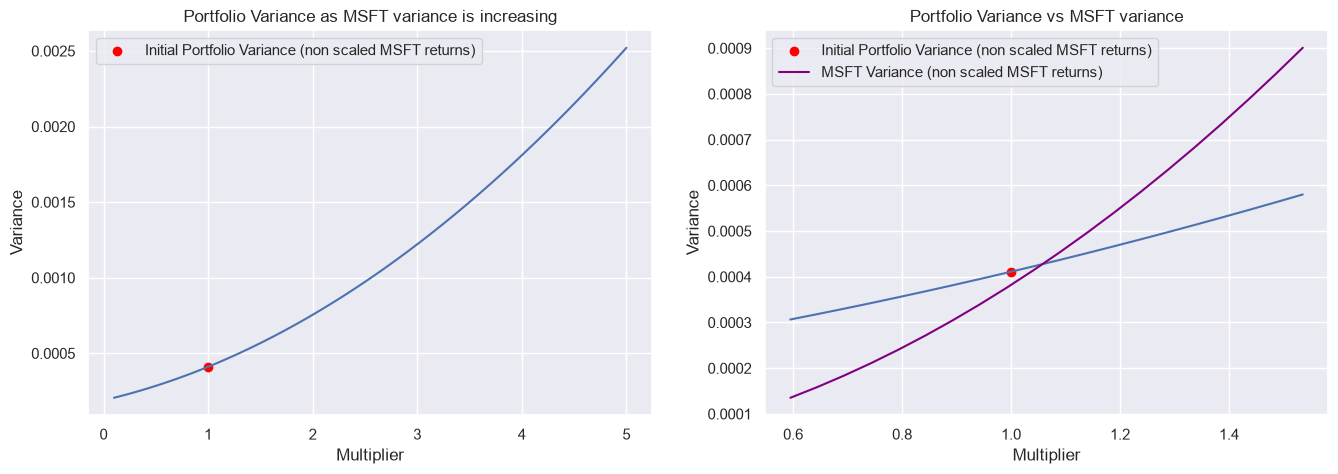

In [11]:
# Figure 3
multipliers = np.linspace(0.1,5,100) # Creating an array that will use to multiply the MSFT returns array.
portfolio_variances = []
msft_variances = []

for multiplier in multipliers:
  temp_returns = r * np.array([1, 1, 1, multiplier, 1]) # Multiplying MSFT returns with a number in order to scale the returns linearly, changing thus the MSFT variance.
  temp_port_variance = w.T @ temp_returns.cov() @ w # Calculating portfolio variance
  msft_variances.append((temp_returns['MSFT']).var())
  portfolio_variances.append(temp_port_variance)
  assert np.allclose(r.corr(), temp_returns.corr()) # For every new array of returns where MSFT returns are multiplied with a number, the correlations remain the same

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16,5))

ax1.plot(multipliers, portfolio_variances)
ax1.scatter(1, port_var, color = 'red', label = "Initial Portfolio Variance (non scaled MSFT returns)")
ax1.set_title("Portfolio Variance as MSFT variance is increasing")
ax1.set_xlabel("Multiplier")
ax1.set_ylabel("Variance")
ax1.legend()

ax2.plot(multipliers[10:30], portfolio_variances[10:30])
ax2.scatter(1, port_var, color = 'red', label = "Initial Portfolio Variance (non scaled MSFT returns)")
ax2.plot(multipliers[10:30], msft_variances[10:30], color = 'purple', label = "MSFT Variance (non scaled MSFT returns)")
ax2.set_title("Portfolio Variance vs MSFT variance")
ax2.set_xlabel("Multiplier")
ax2.set_ylabel("Variance")
ax2.legend()

plt.show()